In [17]:
# %%
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

In [18]:
# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [19]:
# %%
def fft2(x):
    return torch.fft.fft2(x)

def ifft2(k):
    return torch.fft.ifft2(k).real


In [20]:
# %%
def spiral_mask(shape):
    rows, cols = shape

    r = np.linspace(0, 1, 15000)
    t = np.linspace(0, 1, len(r))

    turns = 6

    x = np.cos(2*np.pi*turns*t) * r
    y = np.sin(2*np.pi*turns*t) * r

    x = (x / 2.0 + 0.5) * (cols - 1)
    y = (y / 2.0 + 0.5) * (rows - 1)

    i = np.clip(np.round(rows - y).astype(int), 0, rows-1)
    j = np.clip(np.round(x).astype(int), 0, cols-1)

    mask = np.zeros((rows, cols))
    mask[i, j] = 1

    mask = np.fft.fftshift(mask)

    return torch.tensor(mask, dtype=torch.float32)


In [21]:
# %%
SPIRAL_CACHE = None

def get_spiral(shape):
    global SPIRAL_CACHE

    if SPIRAL_CACHE is None:
        print("Gerando máscara espiral UMA vez...")
        SPIRAL_CACHE = spiral_mask(shape)

    return SPIRAL_CACHE


In [22]:
# %%
def create_mask_from_T(shape, T):

    base_mask = get_spiral(shape)

    prob = 0.6 + 0.4 * (1 - T).item()

    sampling = (torch.rand(shape) < prob).float()

    return base_mask * sampling


In [23]:
# %%
def forward_diffusion(x, T):

    noise = torch.randn_like(x)

    T = T.clamp(0.05, 0.35)

    alpha = (1 - T).view(1,1)

    x_t = torch.sqrt(alpha)*x + torch.sqrt(1-alpha)*noise

    return x_t, noise

In [24]:
# %%
def degradation_pipeline(x, T):

    mask = create_mask_from_T(x.shape, T)

    k = fft2(x)
    k_sub = k * mask

    x_alias = ifft2(k_sub)

    x_t, noise = forward_diffusion(x_alias, T)

    return x_t, noise, mask, k_sub

In [25]:
# %%
class MRIDataset(Dataset):

    def __init__(self, root_dir, size=256):
        self.slices = []
        self.size = size

        print("Carregando dataset...")

        for f in os.listdir(root_dir):
            if f.endswith(".mat"):
                data = loadmat(os.path.join(root_dir, f))
                x = data["x"]

                for k in range(x.shape[2]):
                    img = x[:, :, k]
                    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                    self.slices.append(img.astype(np.float32))

        print("Total slices:", len(self.slices))

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):

        x = torch.tensor(self.slices[idx])  

        # resize
        x = x.unsqueeze(0).unsqueeze(0)
        x = F.interpolate(x, size=(self.size, self.size), mode="bilinear")
        x = x.squeeze()

        T = torch.rand(1, dtype=torch.float32) * 0.3 + 0.05

        x_t, noise, mask, k_sub = degradation_pipeline(x, T)

        return x_t, noise, x, mask, k_sub, T

In [26]:
# %%
dataset_path = "/kaggle/input/datasets/semnickcharlie/brain-dataset1/birn_database_converted_to_matlab"

dataset = MRIDataset(dataset_path)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0  
)


Carregando dataset...
Total slices: 4020


In [27]:
# %%
class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 64)
        )

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, t):

        t = t.view(-1,1)
        t_embed = self.time_embed(t).view(-1,64,1,1)

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x) + t_embed)
        x = F.relu(self.conv3(x))
        x = self.conv4(x)

        return x

In [28]:
# %%
model = DiffusionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [29]:
# %%
epochs = 10

for epoch in range(epochs):
    print(f"\nEpoch {epoch}")

    total_loss = 0

    for i, (x_t, noise, x, mask, k_sub, T) in enumerate(loader):

        x_t = x_t.to(device)
        noise = noise.to(device)
        mask = mask.to(device)
        k_sub = k_sub.to(device)
        T = T.to(device)

        x_t = x_t.unsqueeze(1)
        noise = noise.unsqueeze(1)

        optimizer.zero_grad()

        pred = model(x_t, T)

        loss = ((pred - noise)**2).mean()

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 500 == 0:
            print("batch", i)

    print("Loss:", total_loss/len(loader))



Epoch 0
Gerando máscara espiral UMA vez...
batch 0
batch 500
batch 1000
Loss: 0.11752143020727741

Epoch 1
batch 0
batch 500
batch 1000
Loss: 0.01923954899594262

Epoch 2
batch 0
batch 500
batch 1000
Loss: 0.016270023379567546

Epoch 3
batch 0
batch 500
batch 1000
Loss: 0.014539282247238787

Epoch 4
batch 0
batch 500
batch 1000
Loss: 0.013460674782779384

Epoch 5
batch 0
batch 500
batch 1000
Loss: 0.01272926178682058

Epoch 6
batch 0
batch 500
batch 1000
Loss: 0.012065928945531003

Epoch 7
batch 0
batch 500
batch 1000
Loss: 0.011341208623564658

Epoch 8
batch 0
batch 500
batch 1000
Loss: 0.010989062433404412

Epoch 9
batch 0
batch 500
batch 1000
Loss: 0.010625617245480936


In [30]:
# %%
def data_consistency(x, k_obs, mask):

    k = fft2(x.squeeze(0))
    k = mask * k_obs + (1-mask) * k

    return ifft2(k).unsqueeze(0)

In [31]:
# %%
def reconstruct(model, k_obs, mask):

    k_obs = k_obs.to(device)
    mask = mask.to(device)

    x = torch.randn((1, k_obs.shape[0], k_obs.shape[1]), dtype=torch.float32).to(device)
    x = x.unsqueeze(0)

    for t in np.linspace(0.35, 0.05, 40):

        T = torch.tensor([t], dtype=torch.float32).to(device)

        pred = model(x, T)

        x = x - 0.05 * pred
        x = data_consistency(x, k_obs, mask)

    return x


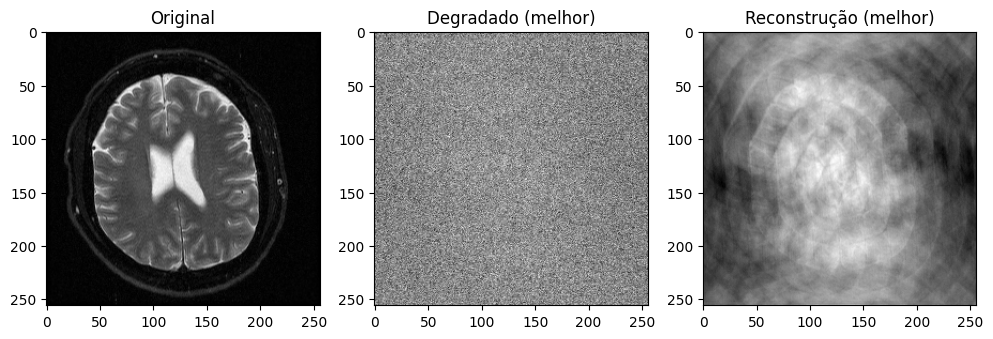

In [32]:
# %%
x_t, noise, x, mask, k_sub, T = dataset[10]

recon = reconstruct(model, k_sub, mask)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(x.numpy(), cmap="gray")

plt.subplot(1,3,2)
plt.title("Degradado (melhor)")
plt.imshow(x_t.numpy(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Reconstrução (melhor)")
plt.imshow(recon.squeeze().detach().cpu().numpy(), cmap="gray")

plt.show()